Import modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt 

from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.colors as mcolors 
import cmocean 
import scipy

import os
import sys
sys.path.append('C:/Users/sebas/git/')

import icewave.tools.matlab_colormaps as matcmaps
import icewave.sebastien.set_graphs as set_graphs
import icewave.sebastien.theory.module_bilayer_viscous_dimensionless as md

import pickle

# PARULA COLORMAP 
parula_map = matcmaps.parula()

plt.rc('text', usetex=True)
plt.rc('font', family='serif', serif='Computer Modern')

def delta_nu(f,nu):
    """ Return thickness of viscous boundary layer for a given frequency 
    Inputs: f, float or np.array
            nu, float 
    Output: delta, float or np.array """
    omega = 2*np.pi*f
    delta = np.sqrt(nu/omega)
    return delta

# Set global parameters
global g
g = 9.81

Define fig folder

In [2]:
#%% Define fig_folder

fig_folder = 'F:/PhD_Manuscript/ch3/Rheology/'
if not os.path.isdir(fig_folder):
    os.mkdir(fig_folder)

Show det M for a set of parameter

C:\Users\sebas\AppData\Local\Temp\ipykernel_14544\58761526.py:56: UserWarning: The following kwargs were not used by contour: 'lw'
  ax.contour(x,y,np.log10(abs(det_values)),15,colors='w',lw = 1)


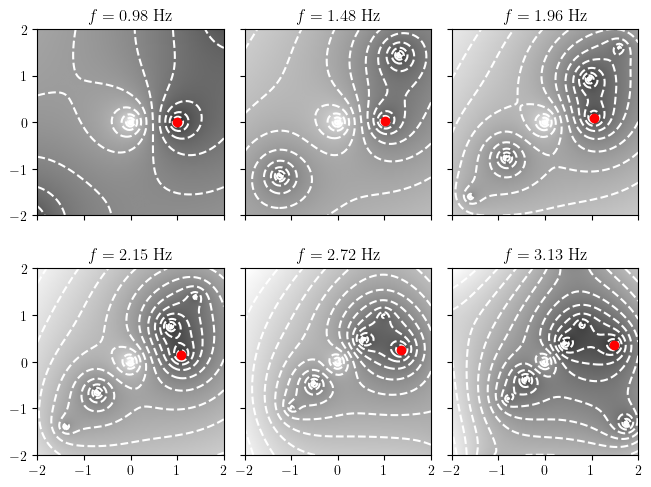

In [28]:
param = {}
param['freqs'] = np.logspace(-1,1,100)
param['h'] = 0.01
param['rho_1'] = 1e3
param['rho_2'] = 1e3
param['nu_1'] = 1e-2
param['nu_2'] = 1e-6

k_array = md.get_wavevector_theory(param['freqs'],param['h'],param['rho_1'],param['rho_2'],
                                   param['nu_1'],param['nu_2'],display = False)

# freqs_list = [0.1,0.3,0.7,1.3,4,8]
freqs_list = [1.0,1.5,2.0,2.2,2.7,3.2]
fig, axs = plt.subplots(ncols = 3,nrows = 2,sharex = True,sharey= True,constrained_layout = True)

for idx_ax,ax in enumerate(axs.reshape(-1)): # loop over all axes of the array axs
    selected_freq = freqs_list[idx_ax]
    idx_freq = np.argmin(abs(selected_freq - param['freqs']))
    f = param['freqs'][idx_freq]
    k_deep = md.gk(f)
    root = k_array[idx_freq]

    inputs = (f,param['h'],param['rho_1'],param['rho_2'],
                            param['nu_1'],param['nu_2'])
    dimensionless = md.dim_numbers(inputs)

    x = np.linspace(-2,2,100)
    y = np.linspace(-2,2,100)
    cmap = 'gray'
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y

    # Evaluate |det(M(k))| over the grid
    det_values = np.zeros_like(Z, dtype=complex)

    for i in range(Z.shape[0]):
        for j in range(Z.shape[1]):
            k = Z[i, j]

            try:
                det_values[i, j] = md.det_M(k,dimensionless)
            except np.linalg.LinAlgError:
                det_values[i, j] = np.nan  # handle singularities or bad evals
                
    extents = np.array((x.min(),x.max(),y.min(),y.max()))
    c = ax.imshow(abs(det_values),cmap = cmap,origin = 'lower',aspect = 'equal',
                interpolation = 'gaussian',extent = extents)
    # divider = make_axes_locatable(ax)
    # cax = divider.append_axes("right", size="2%", pad=0.1)

    # cbar = plt.colorbar(c,cax = cax)
    # cbar.set_label(r'$|\mathrm{det}(\mathcal{M}(k))|)$',labelpad = 5)
    # ax.set_xlabel(r'$\mathrm{Re}(k)/k_0 \; \mathrm{(rad.m^{-1})}$', labelpad = 5)
    # ax.set_ylabel(r'$\mathrm{Im}(k)/k_0 \; \mathrm{(rad.m^{-1})}$', labelpad = 5)

    ax.contour(x,y,np.log10(abs(det_values)),15,colors='w',lw = 1)
    c.set_norm('log')
    ax.plot(np.real(root)/k_deep,np.imag(root)/k_deep,'ro')
    title = r'$f =' + f'{f:.2f}' + r'\; \mathrm{Hz}$'
    ax.set_title(title)
# ax.plot(mp1['k'][idx_nu,idx_h,:]/k_deep,mp1['alpha'][idx_nu,idx_h,:]/k_deep,'o',color = 'tab:green')
# c.set_clim([1e-35,1e-40])


In [13]:
param['freqs'][idx_freq]

np.float64(0.6309573444801934)

(0.08, 15.0)

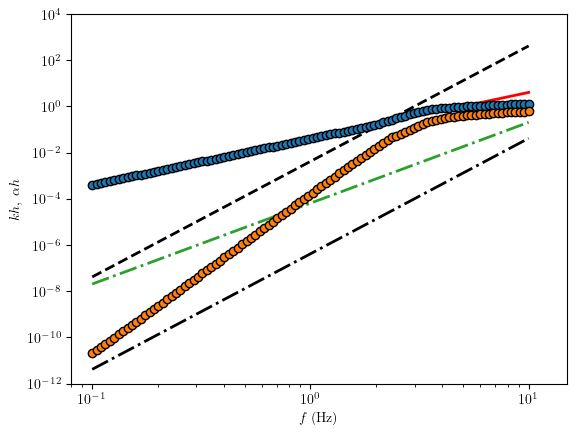

In [25]:
freqs = param['freqs']
k = np.real(k_array)
alpha = np.imag(k_array)

fig,ax = plt.subplots()
lw = 2

b = 5
C1 = 4*param['nu_1']/g**3*(2*np.pi)**b*param['h']
C2 = 4*param['nu_2']/g**3*(2*np.pi)**b*param['h']

b2 = 7/2
CS1 = np.sqrt(param['nu_2'])/g**2*(2*np.pi)**b2*param['h'] #10**(-6)

ax.plot(freqs,md.gk(freqs)*param['h'],'r-',label = r'$\omega^2 = gk$',lw = lw)
ax.plot(freqs,C1*freqs**(b),'--', color = 'k',label = r'Bulk $\nu_1$',lw = lw)
ax.plot(freqs,C2*freqs**(b),'-.', color = 'k',label = r'Bulk $\nu_2$',lw = lw)
ax.plot(freqs,CS1*freqs**(b2),'-.',color = 'tab:green',label = r'Surface $\nu_2$',lw = lw)

ax.plot(freqs,k*param['h'],'o',mec = 'k',color = 'tab:blue', label = '$kh$')
ax.plot(freqs,alpha*param['h'],'o',mec = 'k',color = 'tab:orange',label = r'$\alpha h$')

# ax.vlines(fc,ymin=0,ymax=kmax,linestyle='-.',alpha=0.3,color='k') 

# axs[0].axis([fmin,fmax,0.01,1])#amin,kmax*4])

# ax.legend(['$kh$',r'$\alpha h$',r'$\nu$ = 0',r'Bulk $\nu_1$',r'Bulk $\nu_2$',r'Surface $\nu_2$','$f_c$'])
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$f \; \mathrm{(Hz)}$')
ax.set_ylabel(r'$k h, \; \alpha h$')

ax.set_ylim([1e-12,1e4])
ax.set_xlim([8e-2,1.5e1])

## Solve system implementing non-newtonian fluid

In [62]:
Gpp = 300
rho_w = 1.03e3
omega_0 = 10 # in rad/sec
nu = Gpp/rho_w/omega_0
print(nu)

param = {}
param['freqs'] = np.logspace(-1,1,41)
param['h'] = 0.01
param['rho_1'] = 940
param['rho_2'] = rho_w
param['nu_1'] = Gpp/rho_w/(2*np.pi*param['freqs'])
param['nu_2'] = 1e-6
display = False

params_array = np.array([(f_ex,param['h'],param['rho_1'],param['rho_2'],param['nu_1'][i],param['nu_2'])
                          for i,f_ex in enumerate(param['freqs'])])
dimensionless_array = np.array([md.dim_numbers(params) for params in params_array]) 
omega_array = 2*np.pi*param['freqs']
k0_array = omega_array**2/g

initial_guess = [1 , 0.1] # initial guess for [Re(kappa), Im(kappa)]
k_array = np.zeros(len(param['freqs']),dtype = 'complex')
for i,dimensionless in enumerate(dimensionless_array): # loop over dimensionless parameters
    
    solution = scipy.optimize.fsolve(md.func_real_imag,initial_guess,(dimensionless,))
    root = solution[0] + 1j*solution[1]
    if display:
        print(f'Root of det(M) = {root}')
    initial_guess = solution
    k_array[i] = root*k0_array[i]

0.029126213592233007


C:\Users\sebas\AppData\Local\Temp\ipykernel_14544\3771445649.py:46: UserWarning: The following kwargs were not used by contour: 'lw'
  ax.contour(x,y,np.log10(abs(det_values)),15,colors='w',lw = 1)


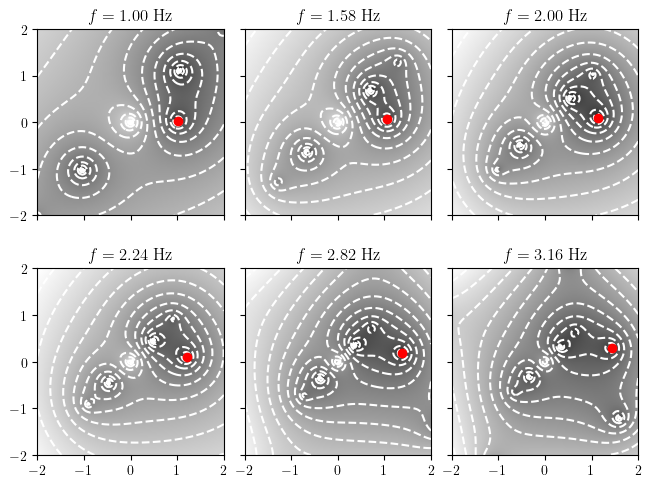

In [64]:
# freqs_list = [0.1,0.3,0.7,1.3,4,8]
freqs_list = [1.0,1.5,2.0,2.2,2.7,3.2]
fig, axs = plt.subplots(ncols = 3,nrows = 2,sharex = True,sharey= True,constrained_layout = True)

for idx_ax,ax in enumerate(axs.reshape(-1)): # loop over all axes of the array axs
    selected_freq = freqs_list[idx_ax]
    idx_freq = np.argmin(abs(selected_freq - param['freqs']))
    f = param['freqs'][idx_freq]
    nu_1 = param['nu_1'][idx_freq]
    k_deep = md.gk(f)
    root = k_array[idx_freq]

    inputs = (f,param['h'],param['rho_1'],param['rho_2'],
                            nu_1,param['nu_2'])
    dimensionless = md.dim_numbers(inputs)

    x = np.linspace(-2,2,100)
    y = np.linspace(-2,2,100)
    cmap = 'gray'
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y

    # Evaluate |det(M(k))| over the grid
    det_values = np.zeros_like(Z, dtype=complex)

    for i in range(Z.shape[0]):
        for j in range(Z.shape[1]):
            k = Z[i, j]

            try:
                det_values[i, j] = md.det_M(k,dimensionless)
            except np.linalg.LinAlgError:
                det_values[i, j] = np.nan  # handle singularities or bad evals
                
    extents = np.array((x.min(),x.max(),y.min(),y.max()))
    c = ax.imshow(abs(det_values),cmap = cmap,origin = 'lower',aspect = 'equal',
                interpolation = 'gaussian',extent = extents)
    # divider = make_axes_locatable(ax)
    # cax = divider.append_axes("right", size="2%", pad=0.1)

    # cbar = plt.colorbar(c,cax = cax)
    # cbar.set_label(r'$|\mathrm{det}(\mathcal{M}(k))|)$',labelpad = 5)
    # ax.set_xlabel(r'$\mathrm{Re}(k)/k_0 \; \mathrm{(rad.m^{-1})}$', labelpad = 5)
    # ax.set_ylabel(r'$\mathrm{Im}(k)/k_0 \; \mathrm{(rad.m^{-1})}$', labelpad = 5)

    ax.contour(x,y,np.log10(abs(det_values)),15,colors='w',lw = 1)
    c.set_norm('log')
    ax.plot(np.real(root)/k_deep,np.imag(root)/k_deep,'ro')
    title = r'$f =' + f'{f:.2f}' + r'\; \mathrm{Hz}$'
    ax.set_title(title)
# ax.plot(mp1['k'][idx_nu,idx_h,:]/k_deep,mp1['alpha'][idx_nu,idx_h,:]/k_deep,'o',color = 'tab:green')
# c.set_clim([1e-35,1e-40])

(0.08, 15.0)

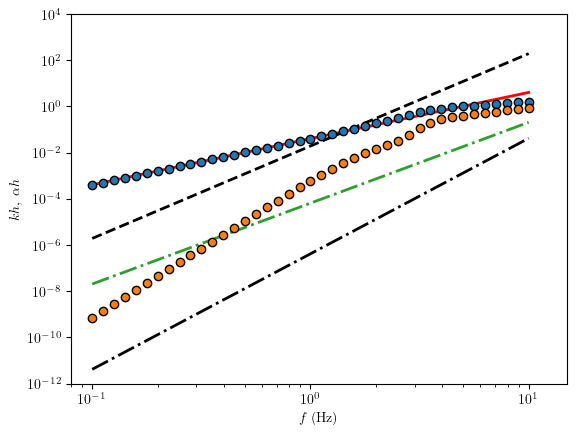

In [65]:
freqs = param['freqs']
k = np.real(k_array)
alpha = np.imag(k_array)

fig,ax = plt.subplots()
lw = 2

b = 5
C1 = 4*param['nu_1']/g**3*(2*np.pi)**b*param['h']
C2 = 4*param['nu_2']/g**3*(2*np.pi)**b*param['h']

b2 = 7/2
CS1 = np.sqrt(param['nu_2'])/g**2*(2*np.pi)**b2*param['h'] #10**(-6)

ax.plot(freqs,md.gk(freqs)*param['h'],'r-',label = r'$\omega^2 = gk$',lw = lw)
ax.plot(freqs,C1*freqs**(b),'--', color = 'k',label = r'Bulk $\nu_1$',lw = lw)
ax.plot(freqs,C2*freqs**(b),'-.', color = 'k',label = r'Bulk $\nu_2$',lw = lw)
ax.plot(freqs,CS1*freqs**(b2),'-.',color = 'tab:green',label = r'Surface $\nu_2$',lw = lw)

ax.plot(freqs,k*param['h'],'o',mec = 'k',color = 'tab:blue', label = '$kh$')
ax.plot(freqs,alpha*param['h'],'o',mec = 'k',color = 'tab:orange',label = r'$\alpha h$')

# ax.vlines(fc,ymin=0,ymax=kmax,linestyle='-.',alpha=0.3,color='k') 

# axs[0].axis([fmin,fmax,0.01,1])#amin,kmax*4])

# ax.legend(['$kh$',r'$\alpha h$',r'$\nu$ = 0',r'Bulk $\nu_1$',r'Bulk $\nu_2$',r'Surface $\nu_2$','$f_c$'])
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$f \; \mathrm{(Hz)}$')
ax.set_ylabel(r'$k h, \; \alpha h$')

ax.set_ylim([1e-12,1e4])
ax.set_xlim([8e-2,1.5e1])

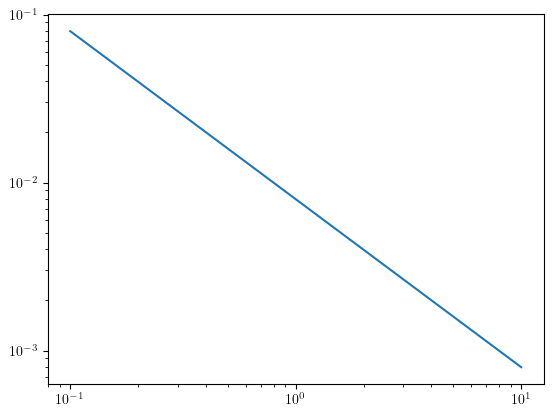

In [53]:
fig, ax = plt.subplots()
y = [param[4] for param in params_array]
ax.plot(param['freqs'],y)
ax.set_yscale('log')
ax.set_xscale('log')

## Solve system using a complex viscosity

In [102]:
Gp = 600
Gpp = 200
rho_w = 1.03e3
omega_0 = 10 # in rad/sec
nu = Gpp/rho_w/omega_0
print(nu)

param = {}
param['freqs'] = np.logspace(-1,1,101)
param['h'] = 0.01
param['rho_1'] = 940
param['rho_2'] = rho_w
param['nu_1'] = Gpp/rho_w/(2*np.pi*param['freqs']) - 1j*Gp/rho_w/(2*np.pi*param['freqs'])
param['nu_2'] = 1e-6
display = False

params_array = np.array([(f_ex,param['h'],param['rho_1'],param['rho_2'],param['nu_1'][i],param['nu_2'])
                          for i,f_ex in enumerate(param['freqs'])])
dimensionless_array = np.array([md.dim_numbers(params) for params in params_array]) 
omega_array = 2*np.pi*param['freqs']
k0_array = omega_array**2/g

initial_guess = [1 , 0.1] # initial guess for [Re(kappa), Im(kappa)]
k_array = np.zeros(len(param['freqs']),dtype = 'complex')
for i,dimensionless in enumerate(dimensionless_array): # loop over dimensionless parameters
    
    solution = scipy.optimize.fsolve(md.func_real_imag,initial_guess,(dimensionless,))
    root = solution[0] + 1j*solution[1]
    if display:
        print(f'Root of det(M) = {root}')
    initial_guess = solution
    k_array[i] = root*k0_array[i]

0.019417475728155338


C:\Users\sebas\AppData\Local\Temp\ipykernel_14544\1040151427.py:46: UserWarning: The following kwargs were not used by contour: 'lw'
  ax.contour(x,y,np.log10(abs(det_values)),15,colors='w',lw = 1)


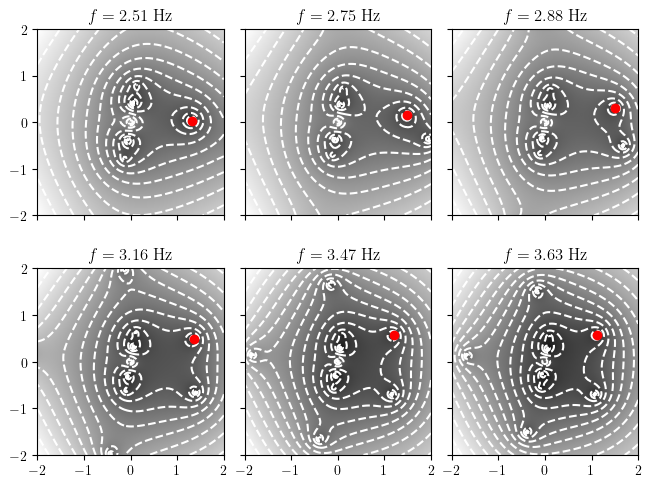

In [103]:
# freqs_list = [0.1,0.3,0.7,1.3,4,8]
freqs_list = [2.5,2.7,2.9,3.1,3.4,3.7]
fig, axs = plt.subplots(ncols = 3,nrows = 2,sharex = True,sharey= True,constrained_layout = True)

for idx_ax,ax in enumerate(axs.reshape(-1)): # loop over all axes of the array axs
    selected_freq = freqs_list[idx_ax]
    idx_freq = np.argmin(abs(selected_freq - param['freqs']))
    f = param['freqs'][idx_freq]
    nu_1 = param['nu_1'][idx_freq]
    k_deep = md.gk(f)
    root = k_array[idx_freq]

    inputs = (f,param['h'],param['rho_1'],param['rho_2'],
                            nu_1,param['nu_2'])
    dimensionless = md.dim_numbers(inputs)

    x = np.linspace(-2,2,100)
    y = np.linspace(-2,2,100)
    cmap = 'gray'
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y

    # Evaluate |det(M(k))| over the grid
    det_values = np.zeros_like(Z, dtype=complex)

    for i in range(Z.shape[0]):
        for j in range(Z.shape[1]):
            k = Z[i, j]

            try:
                det_values[i, j] = md.det_M(k,dimensionless)
            except np.linalg.LinAlgError:
                det_values[i, j] = np.nan  # handle singularities or bad evals
                
    extents = np.array((x.min(),x.max(),y.min(),y.max()))
    c = ax.imshow(abs(det_values),cmap = cmap,origin = 'lower',aspect = 'equal',
                interpolation = 'gaussian',extent = extents)
    # divider = make_axes_locatable(ax)
    # cax = divider.append_axes("right", size="2%", pad=0.1)

    # cbar = plt.colorbar(c,cax = cax)
    # cbar.set_label(r'$|\mathrm{det}(\mathcal{M}(k))|)$',labelpad = 5)
    # ax.set_xlabel(r'$\mathrm{Re}(k)/k_0 \; \mathrm{(rad.m^{-1})}$', labelpad = 5)
    # ax.set_ylabel(r'$\mathrm{Im}(k)/k_0 \; \mathrm{(rad.m^{-1})}$', labelpad = 5)

    ax.contour(x,y,np.log10(abs(det_values)),15,colors='w',lw = 1)
    c.set_norm('log')
    ax.plot(np.real(root)/k_deep,np.imag(root)/k_deep,'ro')
    title = r'$f =' + f'{f:.2f}' + r'\; \mathrm{Hz}$'
    ax.set_title(title)
# ax.plot(mp1['k'][idx_nu,idx_h,:]/k_deep,mp1['alpha'][idx_nu,idx_h,:]/k_deep,'o',color = 'tab:green')
# c.set_clim([1e-35,1e-40])

(0.08, 15.0)

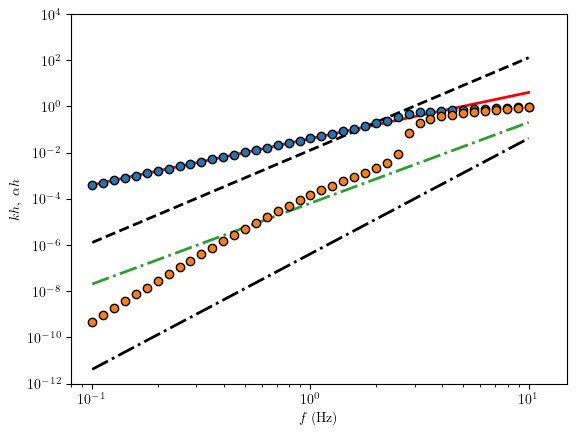

In [99]:
freqs = param['freqs']
k = np.real(k_array)
alpha = np.imag(k_array)

fig,ax = plt.subplots()
lw = 2

b = 5
C1 = 4*np.real(param['nu_1'])/g**3*(2*np.pi)**b*param['h']
C2 = 4*param['nu_2']/g**3*(2*np.pi)**b*param['h']

b2 = 7/2
CS1 = np.sqrt(param['nu_2'])/g**2*(2*np.pi)**b2*param['h'] #10**(-6)

ax.plot(freqs,md.gk(freqs)*param['h'],'r-',label = r'$\omega^2 = gk$',lw = lw)
ax.plot(freqs,C1*freqs**(b),'--', color = 'k',label = r'Bulk $\nu_1$',lw = lw)
ax.plot(freqs,C2*freqs**(b),'-.', color = 'k',label = r'Bulk $\nu_2$',lw = lw)
ax.plot(freqs,CS1*freqs**(b2),'-.',color = 'tab:green',label = r'Surface $\nu_2$',lw = lw)

ax.plot(freqs,k*param['h'],'o',mec = 'k',color = 'tab:blue', label = '$kh$')
ax.plot(freqs,alpha*param['h'],'o',mec = 'k',color = 'tab:orange',label = r'$\alpha h$')

# ax.vlines(fc,ymin=0,ymax=kmax,linestyle='-.',alpha=0.3,color='k') 

# axs[0].axis([fmin,fmax,0.01,1])#amin,kmax*4])

# ax.legend(['$kh$',r'$\alpha h$',r'$\nu$ = 0',r'Bulk $\nu_1$',r'Bulk $\nu_2$',r'Surface $\nu_2$','$f_c$'])
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$f \; \mathrm{(Hz)}$')
ax.set_ylabel(r'$k h, \; \alpha h$')

ax.set_ylim([1e-12,1e4])
ax.set_xlim([8e-2,1.5e1])

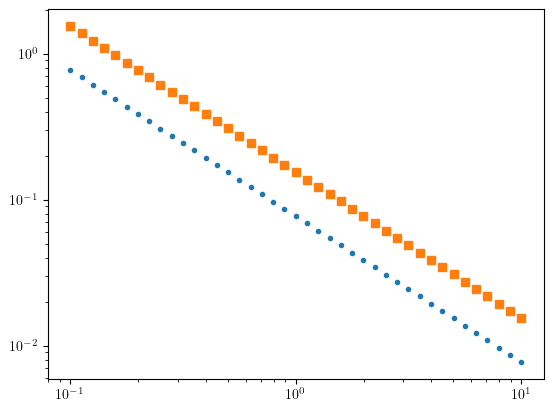

In [96]:
fig, ax = plt.subplots()
y = [param[4] for param in params_array]
ax.plot(param['freqs'],abs(np.real(y)),'.',color = 'tab:blue')
ax.plot(param['freqs'],abs(np.imag(y)),'s',color = 'tab:orange')
ax.set_yscale('log')
ax.set_xscale('log')

In [80]:
y

[np.complex128(0.7725968111257056-1.545193622251411j),
 np.complex128(0.6885776327149252-1.3771552654298505j),
 np.complex128(0.6136954611350909-1.2273909222701815j),
 np.complex128(0.5469566554650712-1.0939133109301424j),
 np.complex128(0.4874756323017406-0.9749512646034812j),
 np.complex128(0.4344631146062671-0.8689262292125342j),
 np.complex128(0.3872156584773445-0.7744313169546889j),
 np.complex128(0.3451063188780093-0.6902126377560186j),
 np.complex128(0.3075763304559094-0.6151526609118187j),
 np.complex128(0.27412769306656415-0.5482553861331283j),
 np.complex128(0.24431656361401474-0.48863312722802943j),
 np.complex128(0.21774736652260354-0.4354947330452071j),
 np.complex128(0.19406754468942294-0.3881350893788459j),
 np.complex128(0.1729628812657608-0.3459257625315216j),
 np.complex128(0.15415333019042493-0.30830666038084986j),
 np.complex128(0.13738930014865727-0.27477860029731455j),
 np.complex128(0.12244834264702951-0.24489668529405906j),
 np.complex128(0.10913220025708739-0.2